# ML-Based Regions

<div style="text-align: justify">

The following notebook defines ML-based analysis regions — **Control Region (CR)**, **Validation Region (VR)**, and **Signal Region (SR)** — using the signal output score from either BDT (XGBoost) or DNN (PyTorch) classifiers trained in stages **04a/04b**. It then generates signal score distributions with region threshold overlays, computes expected CLs significance for each signal mass point using **pyhf**, and produces kinematic distribution plots per region with stacked backgrounds and optional signal overlays.

</div>

## Pipeline Summary

| Step | Module | Description |
|------|--------|-------------|
| Config | `hydra.compose` | Load analysis and ML regions configuration |
| Load | `io.load_dataframe` | Load MC DataFrame and predictions parquet |
| Labels | `eda.utils` | Derive ordered class names and display labels |
| Analysis Frame | `regions.construction` | Join MC metadata with predictions for test-set events |
| Region Split | `regions.construction` | Threshold-based CR/VR/SR partitioning on signal score |
| Score Plots | `regions.plots` | Signal output score distributions with threshold lines |
| Significance | `regions.significance` | pyhf CLs expected significance grid per mass point |
| Kinematic Plots | `regions.plots` | Stacked background + signal overlay distributions per region |
| Save | `visualization.plots.save_figure` | Persist all plots to disk |

The same pipeline is available as a CLI via `python regions.py` or `make regions`.

## Initialization

### Libraries

Configuration:
* [Hydra](https://hydra.cc/)
* [OmegaConf](https://omegaconf.readthedocs.io/)
* [pyrootutils](https://github.com/ashleve/pyrootutils)

Data Processing:
* [Pandas](https://pandas.pydata.org/)
* [NumPy](https://numpy.org/)

Data Visualization:
* [Atlas MPL Style](https://atlas-mpl.readthedocs.io/en/latest/styles.html)
* [Matplotlib](https://matplotlib.org/)
* [Seaborn](https://seaborn.pydata.org/)

Statistics:
* [pyhf](https://pyhf.readthedocs.io/)

Serialization:
* [Apache Parquet](https://parquet.apache.org/)

### Notebook

Activating autoreload of imported modules.

In [1]:
%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = "retina"

Initializing the project root.

In [2]:
import pyrootutils

path = pyrootutils.setup_root(
    search_from=__file__ if "__file__" in locals() else ".",
    indicator=".gitignore",
    pythonpath=True,
)

Suppressing unessential warnings and applying ATLAS style.

In [3]:
from src.utils import suppress_warnings
from src.visualization.plots import apply_atlas_style

suppress_warnings()
apply_atlas_style()

## Configuration

Loading the Hydra configuration. Change the `model_type` override to switch between BDT and DNN predictions.

In [4]:
from hydra import compose, initialize_config_dir

initialize_config_dir(config_dir=str(path / "configs"), version_base="1.3")
cfg = compose(config_name="config")

model_type = cfg.ml_regions.model_type
print(f"Model type: {model_type}")

Model type: bdt


## Deserialization

Resolving input and output directories from config.

In [5]:
from src.processing.analysis import get_output_paths

output_paths = get_output_paths(cfg)
dataframes_dir = path / output_paths["dataframes_dir"]
plots_dir = path / output_paths["plots_dir"] / "ml_regions"

plots_dir.mkdir(parents=True, exist_ok=True)

Deriving ordered class names and display labels from `eventOrigin`.

In [6]:
from omegaconf import OmegaConf
from src.eda.utils import get_class_names, get_class_labels
from src.processing.io import load_dataframe

df_mc = load_dataframe(dataframes_dir / "mc.parquet")

display_labels = OmegaConf.to_container(cfg.merge.display_labels, resolve=True)
class_names = get_class_names(df_mc)
class_labels = get_class_labels(df_mc, display_labels=display_labels)
n_classes = len(class_names)

print(f"Classes ({n_classes}): {class_names}")
class_labels

Classes (6): ['topquarks', 'wtaunu', 'ztautau', 'diboson', 'other', 'signal']


['top quarks',
 '$W \\rightarrow \\tau\\nu$',
 '$Z \\rightarrow \\tau\\tau$',
 'diboson',
 'other',
 'signal']

Loading test-set predictions.

In [7]:
import numpy as np

predictions_df = load_dataframe(dataframes_dir / f"{model_type}_predictions.parquet")

y_true = predictions_df["y_true"].to_numpy()
y_pred = predictions_df["y_pred"].to_numpy()
y_proba = predictions_df[[f"p_{name}" for name in class_names]].to_numpy()

print(f"Predictions loaded: {len(predictions_df):,} events")
predictions_df.head()

Predictions loaded: 1,965,434 events


,y_true,y_pred,p_topquarks,p_wtaunu,p_ztautau,p_diboson,p_other,p_signal
0,5,5,0.000031,1.381659e-07,0.000002,0.000056,0.000151,0.999760
1,5,5,0.000928,6.356762e-04,0.005019,0.007705,0.000477,0.985235
2,3,3,0.085514,3.655023e-01,0.063403,0.471819,0.011504,0.002257
3,2,2,0.029626,2.114606e-01,0.522861,0.219309,0.008626,0.008117
4,0,4,0.233642,7.909787e-03,0.001276,0.017420,0.735775,0.003977


Building the analysis frame by joining MC metadata with predictions. The test-set indices are recovered by reproducing the same stratified split used during training.

In [8]:
from src.models.splits import prepare_features_target, train_test_split, kfold_split
from src.regions.construction import build_analysis_frame

X, y, weights = prepare_features_target(df_mc)
split_strategy = cfg.pipeline.split_strategy

if split_strategy == "train_test":
    _, X_test, _, _, _, _ = train_test_split(
        X, y, weights, test_size=cfg.data.test_split, seed=cfg.seed,
    )
    test_indices = X_test.index
elif split_strategy == "k_fold":
    test_indices = X.index
else:
    raise ValueError(f"Unknown split_strategy: {split_strategy!r}")

analysis_df = build_analysis_frame(df_mc, predictions_df, test_indices)
print(f"Analysis frame: {len(analysis_df):,} events, {len(analysis_df.columns)} columns")
analysis_df.head()

Analysis frame: 1,965,434 events, 66 columns


,nVtx,LeptonVeto,jet_n,jet_n_btag,sumMTJet,sumMTTauJet,met,met_phi,METSig,meff,...,tau_n,class_weight,y_true,y_pred,p_topquarks,p_wtaunu,p_ztautau,p_diboson,p_other,p_signal
0,10,False,8,1,3838845.000,4.510214e+06,598158.125000,-2.484009,17.102732,2.508975e+06,...,1,0.414898,5,5,0.000031,1.381659e-07,0.000002,0.000056,0.000151,0.999760
1,15,False,4,1,1985709.125,2.165948e+06,504009.437500,-0.025953,14.404121,1.761620e+06,...,1,0.414898,5,5,0.000928,6.356762e-04,0.005019,0.007705,0.000477,0.985235
2,16,True,5,0,1121431.000,1.154771e+06,250967.687500,-2.127314,9.163142,7.527201e+05,...,1,0.446206,3,3,0.085514,3.655023e-01,0.063403,0.471819,0.011504,0.002257
3,15,True,5,0,1023231.375,1.033374e+06,208686.421875,2.224078,7.019954,9.594424e+05,...,1,0.356072,2,2,0.029626,2.114606e-01,0.522861,0.219309,0.008626,0.008117
4,23,False,4,1,952667.875,9.687097e+05,224582.890625,0.083161,10.907758,6.063149e+05,...,1,0.723287,0,4,0.233642,7.909787e-03,0.001276,0.017420,0.735775,0.003977


## Region Construction

Splitting events into Control, Validation, and Signal Regions based on the signal output score thresholds.

In [9]:
from src.regions.construction import RegionThresholds, split_into_regions

t = cfg.ml_regions.thresholds
thresholds = RegionThresholds(
    control=t.control,
    validation=t.validation,
    signal=t.signal,
)

regions = split_into_regions(analysis_df, thresholds)

for name, rdf in regions.items():
    print(f"{name}: {len(rdf):,} events")

CR: 1,654,750 events
VR: 48,649 events
SR: 262,035 events


## Signal Output Score Distributions

Stacked histograms of the signal output score, shown in binary (background vs signal) and multiclass (per-class) breakdowns, with and without event weights, on linear and logarithmic scales. Region threshold lines and coloured spans indicate the CR/VR/SR boundaries.

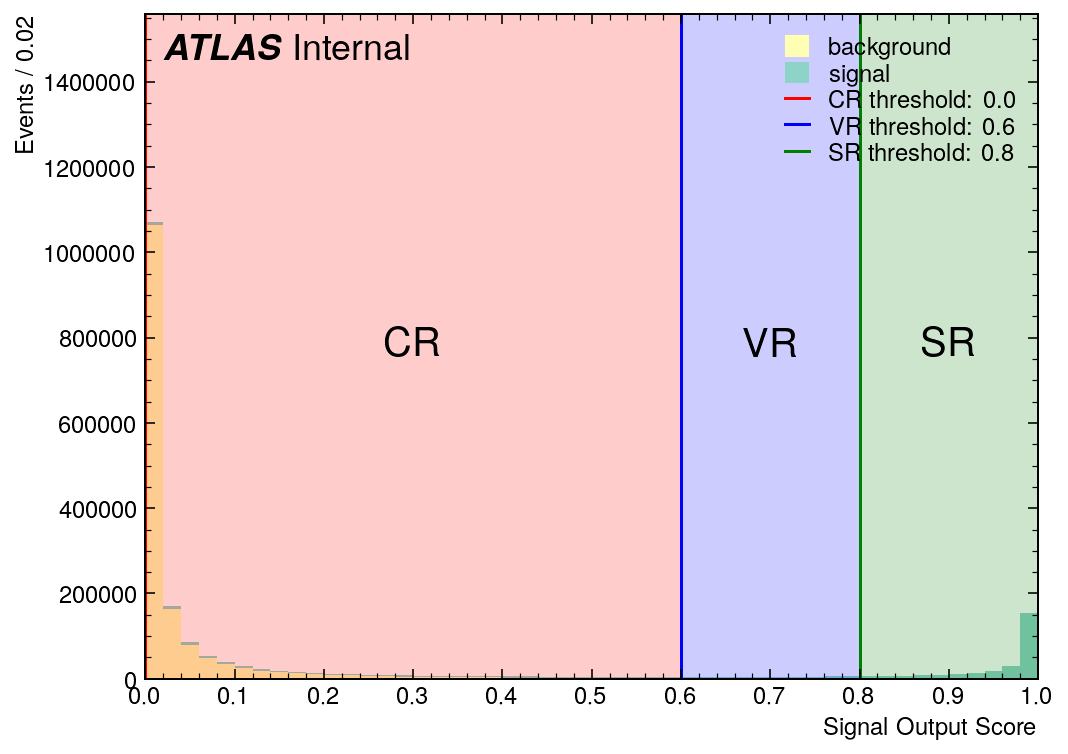

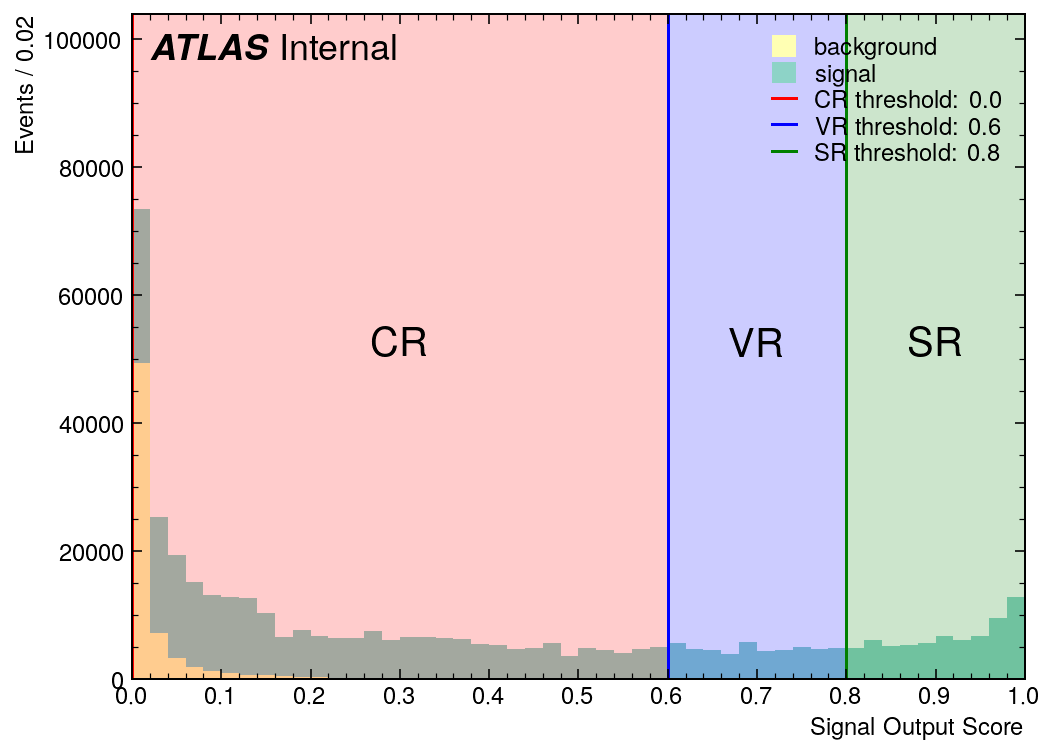

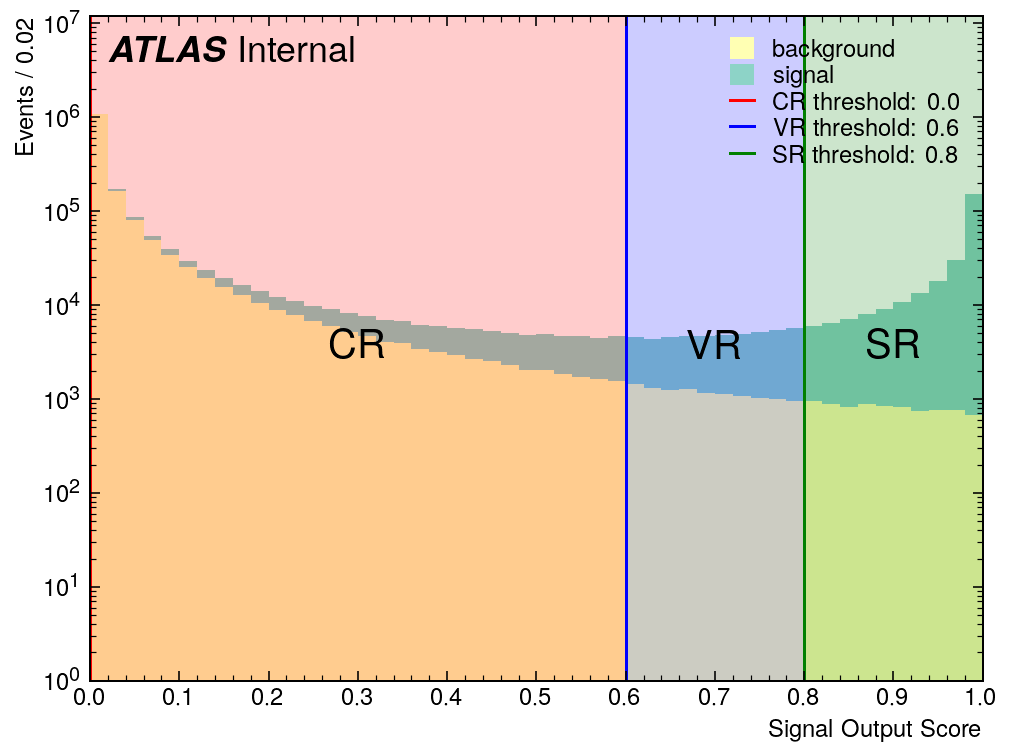

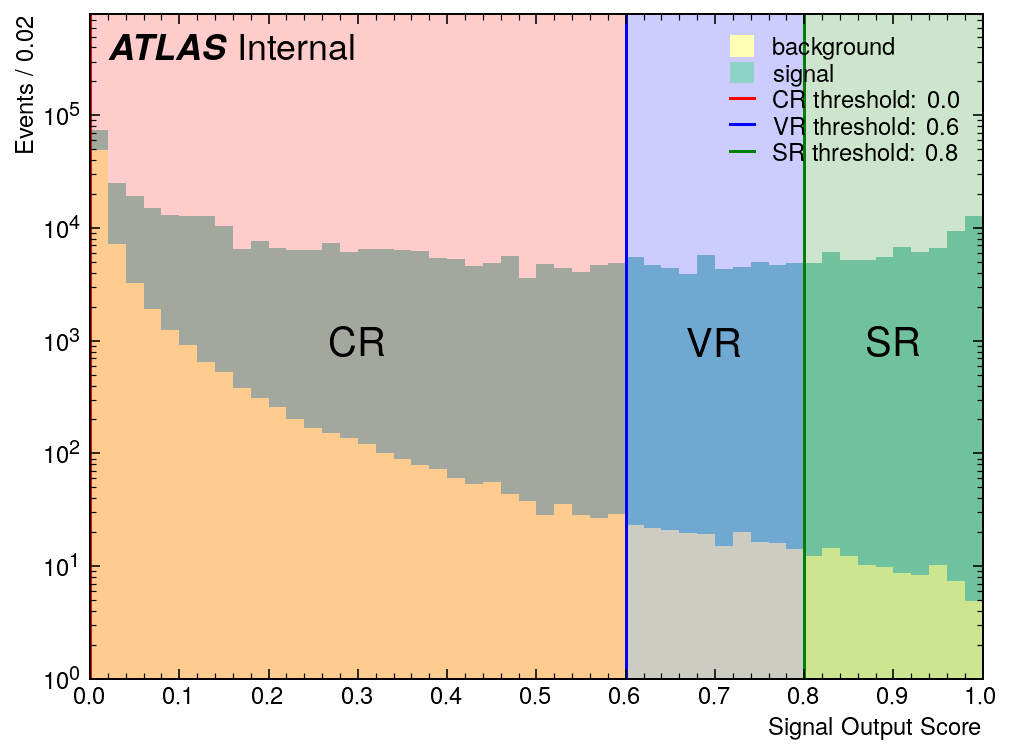

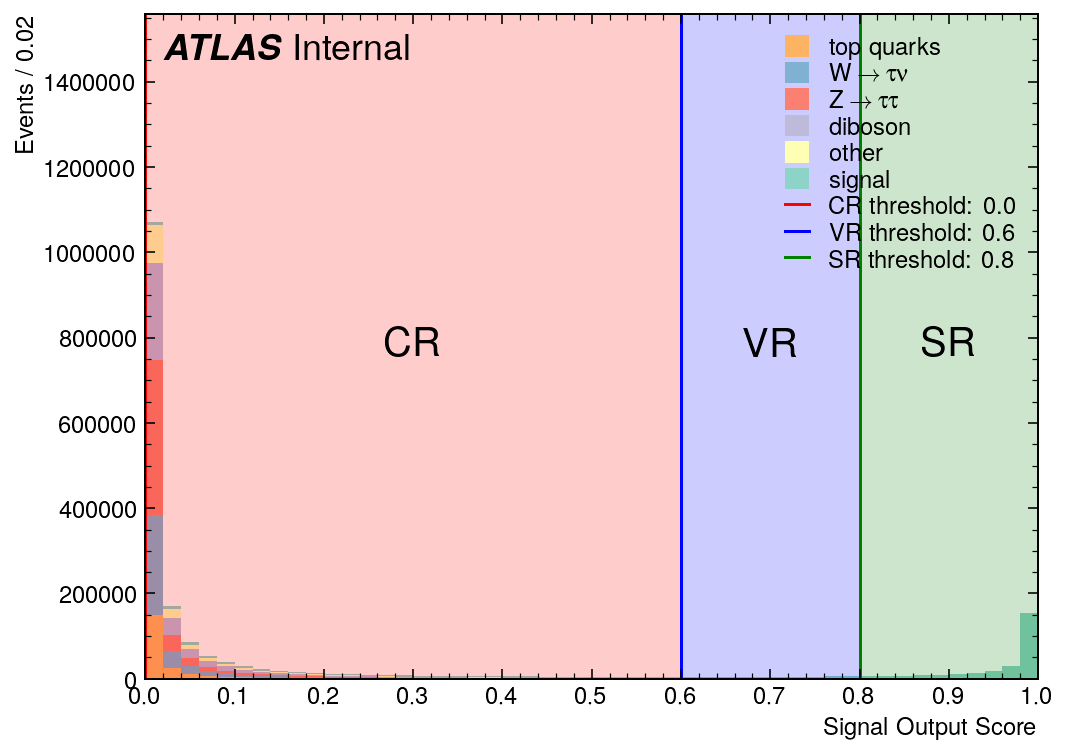

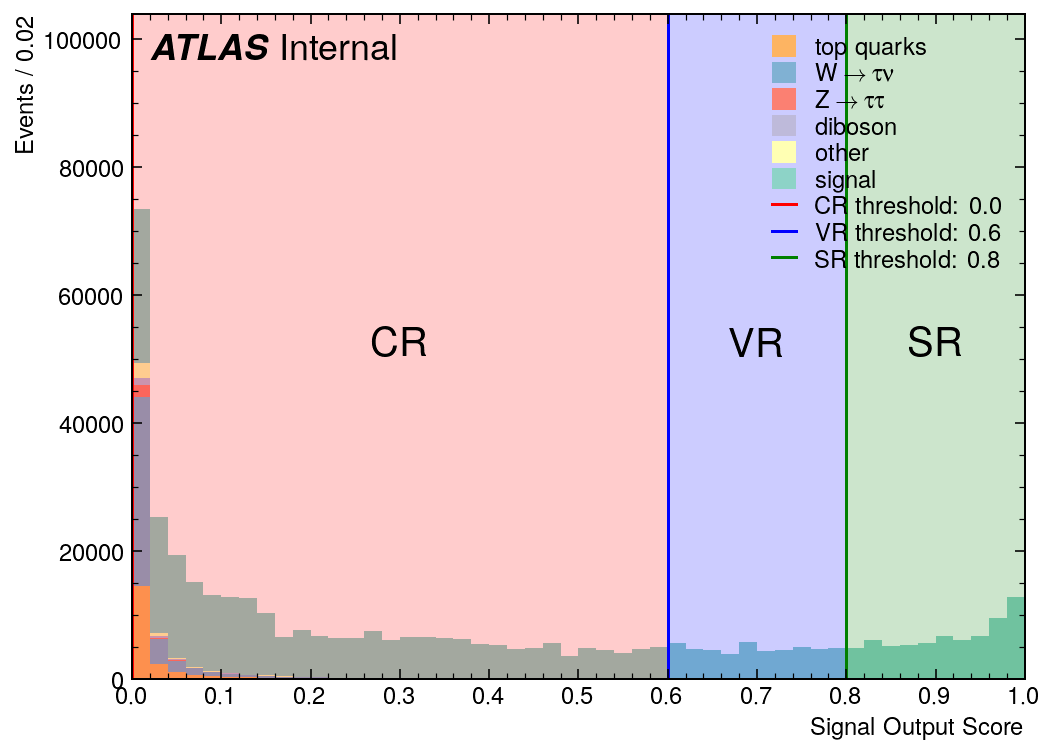

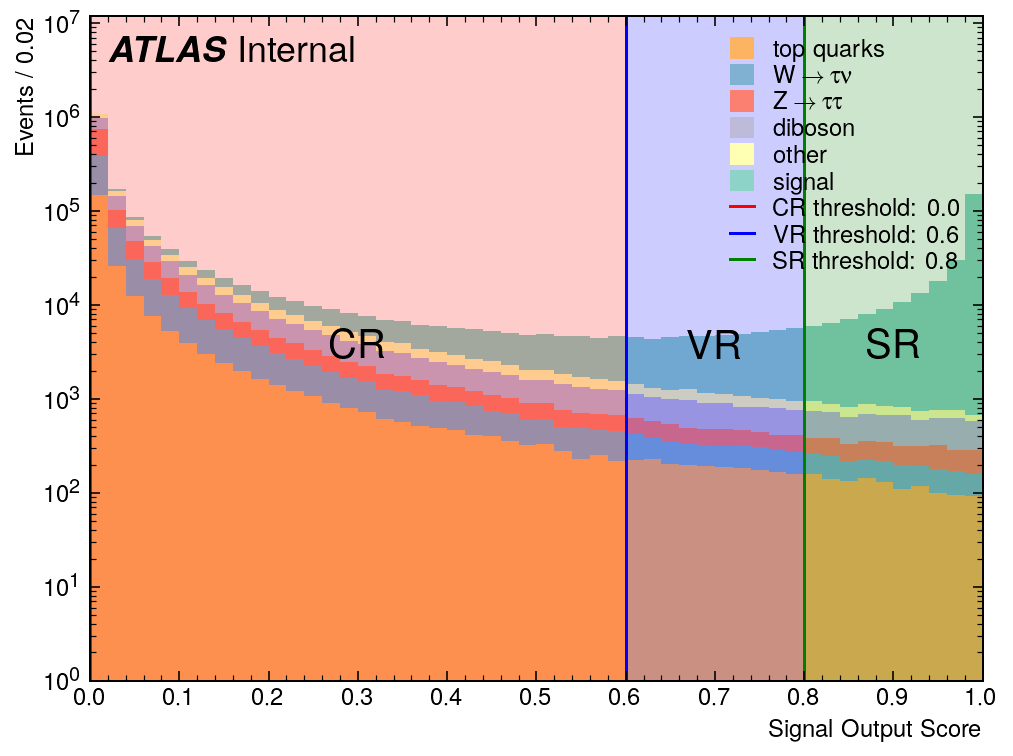

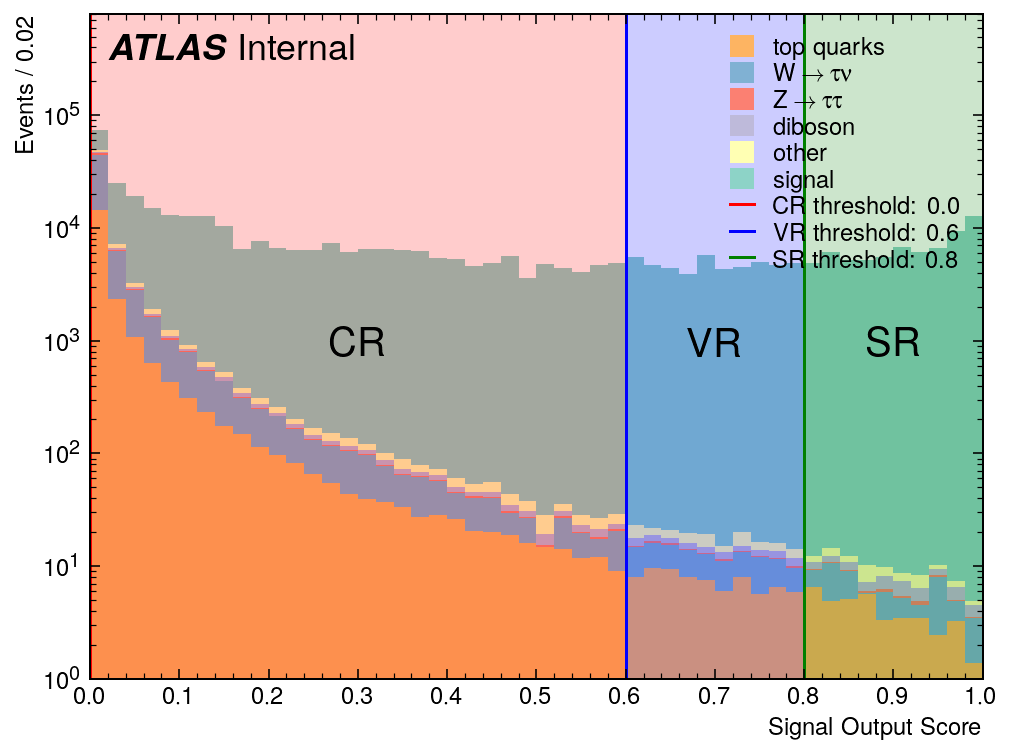

In [10]:
from src.regions.plots import plot_signal_score
from src.visualization.plots import save_figure

score_cfg = cfg.ml_regions.score_plots
threshold_tuple = (t.control, t.validation, t.signal)

for mode in score_cfg.modes:
    for scale in score_cfg.scales:
        for weighted in score_cfg.weighted:
            fig = plot_signal_score(
                analysis_df,
                class_labels,
                thresholds=threshold_tuple,
                mode=mode,
                weighted=weighted,
                scale=scale,
                bins=score_cfg.bins,
            )
            tag = f"score_{mode}_{scale}_{'w' if weighted else 'uw'}"
            save_figure(fig, plots_dir / f"{tag}.png")
            fig.show()

## Significance Grid

Computing the expected CLs significance for each signal mass point in the Signal Region using pyhf. The results are displayed as heatmaps for each signal production type (gluino-gluino and squark-squark).

In [11]:
from src.regions.significance import compute_significance_grid, construct_grid

background_names = list(OmegaConf.to_container(cfg.merge.primary_groups, resolve=True).keys())

sig_results = compute_significance_grid(
    sr_df=regions["SR"],
    signal_threshold=t.signal,
    background_names=background_names,
    bins=cfg.ml_regions.significance.bins,
    bkg_uncertainty_frac=cfg.ml_regions.significance.bkg_uncertainty,
)

CLs significance: 100%|██████████| 304/304 [01:26<00:00,  3.49it/s]

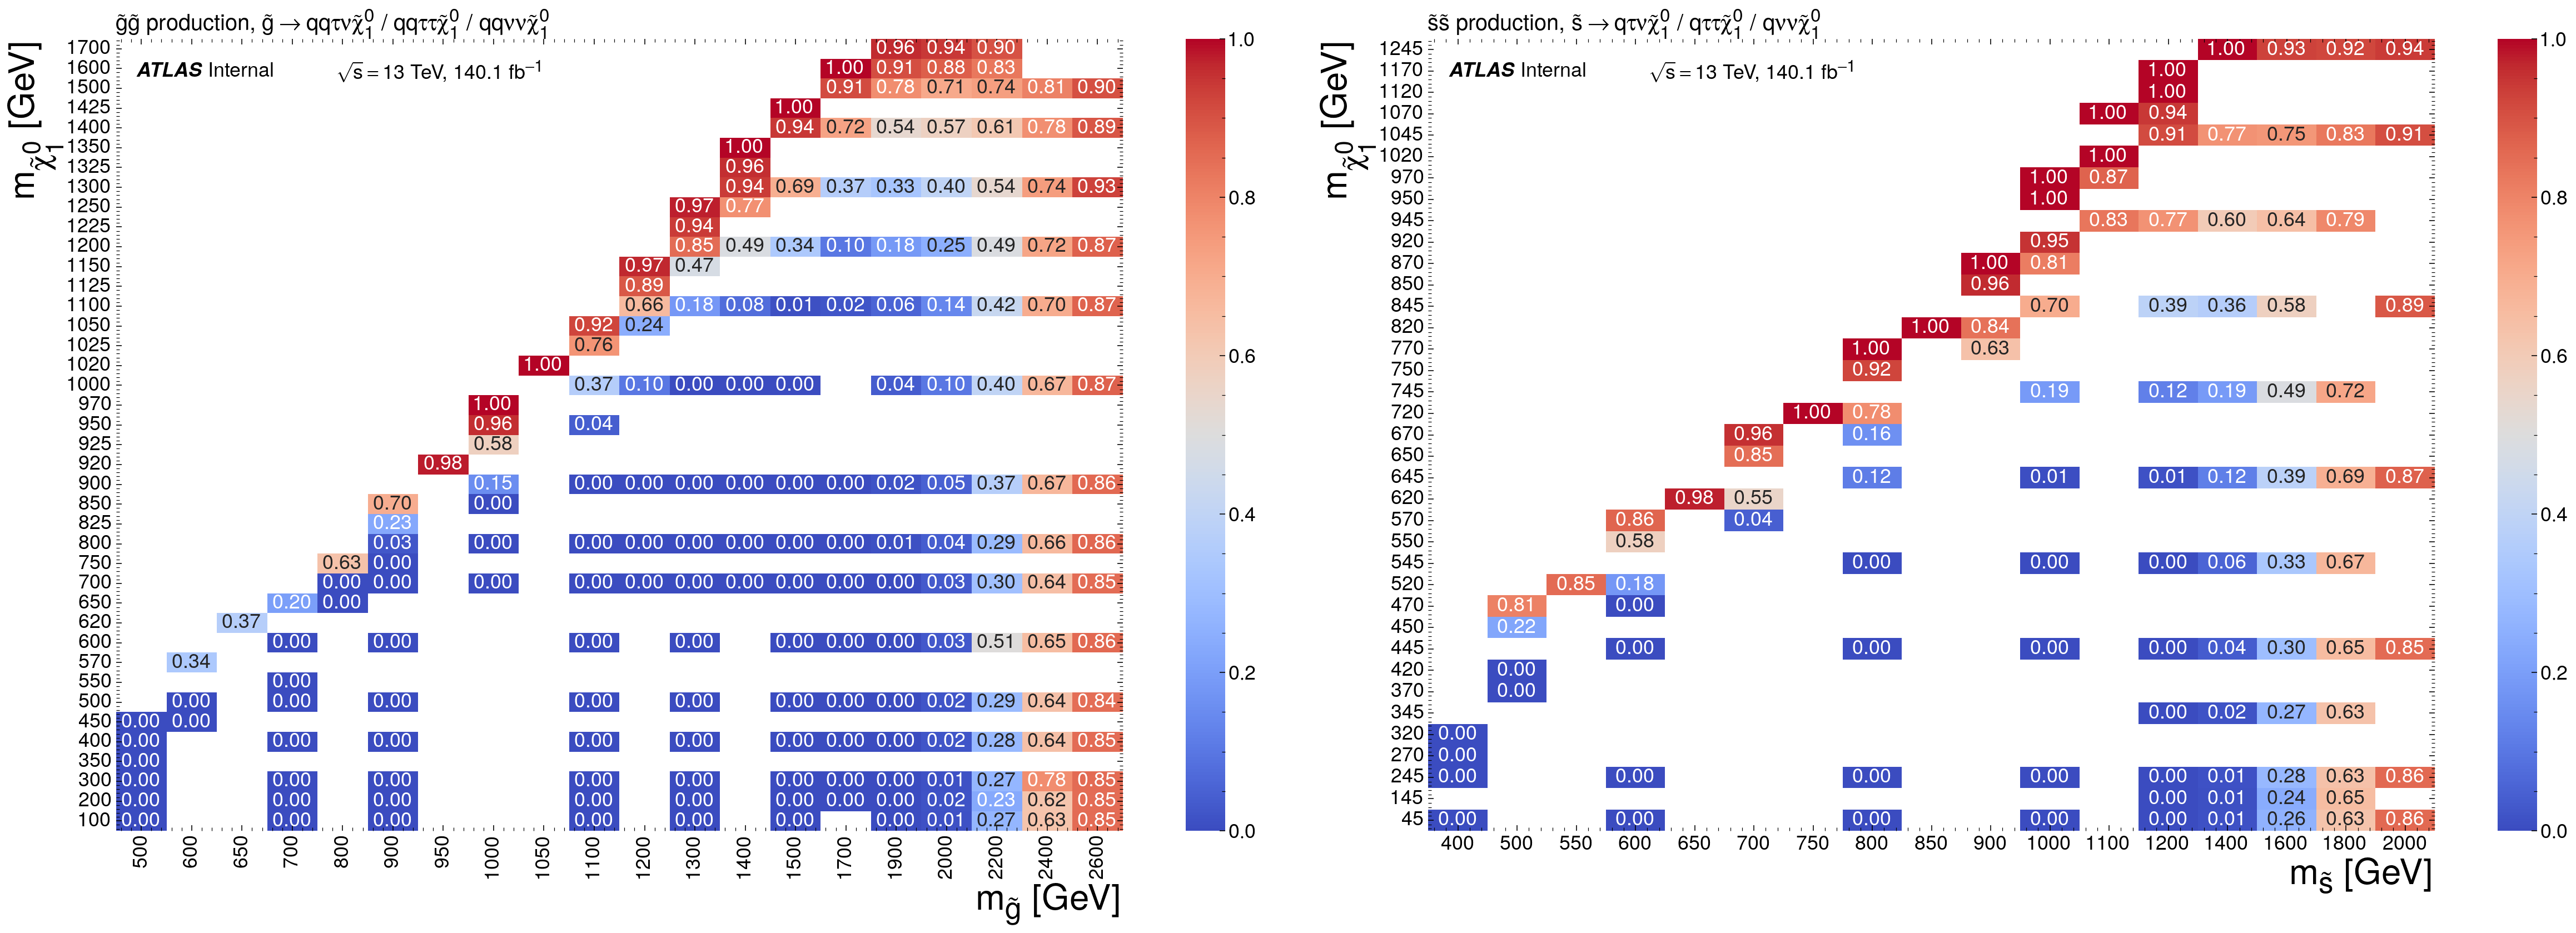

In [12]:
from src.regions.plots import plot_significance_grid

grids = {}
for prefix, (cls_vals, m1, m2) in sig_results.items():
    grid, x_ticks, y_ticks = construct_grid(m1, m2, cls_vals)
    grids[prefix] = (grid, x_ticks, y_ticks)

run_label = cfg.analysis.run
fig = plot_significance_grid(grids, run_label=run_label)
save_figure(fig, plots_dir / "significance_grid.png")
fig.show()

## Kinematic Distributions

Plotting kinematic feature distributions per region with stacked backgrounds and optional signal overlays. Each background class is shown as a filled bar and the total MC is outlined in red. Signal mass points are shown as dashed step histograms.

In [13]:
from src.regions.plots import plot_kinematic_distribution
from src.processing.validation import METADATA_COLUMNS

training_features = [
    c for c in df_mc.columns
    if c not in METADATA_COLUMNS and df_mc[c].dtype.kind in ("i", "u", "f")
]

background_names = list(OmegaConf.to_container(cfg.merge.primary_groups, resolve=True).keys())
background_display = OmegaConf.to_container(cfg.merge.display_labels, resolve=True)

kin_cfg = cfg.ml_regions.kinematic_plots
include_signal = kin_cfg.include_signal

print(f"Training features ({len(training_features)}): {training_features[:10]}...")
print(f"Background classes: {background_names}")

Training features (52): ['nVtx', 'jet_n', 'jet_n_btag', 'sumMTJet', 'sumMTTauJet', 'met', 'met_phi', 'METSig', 'meff', 'ht']...
Background classes: ['topquarks', 'wtaunu', 'ztautau', 'diboson', 'other']


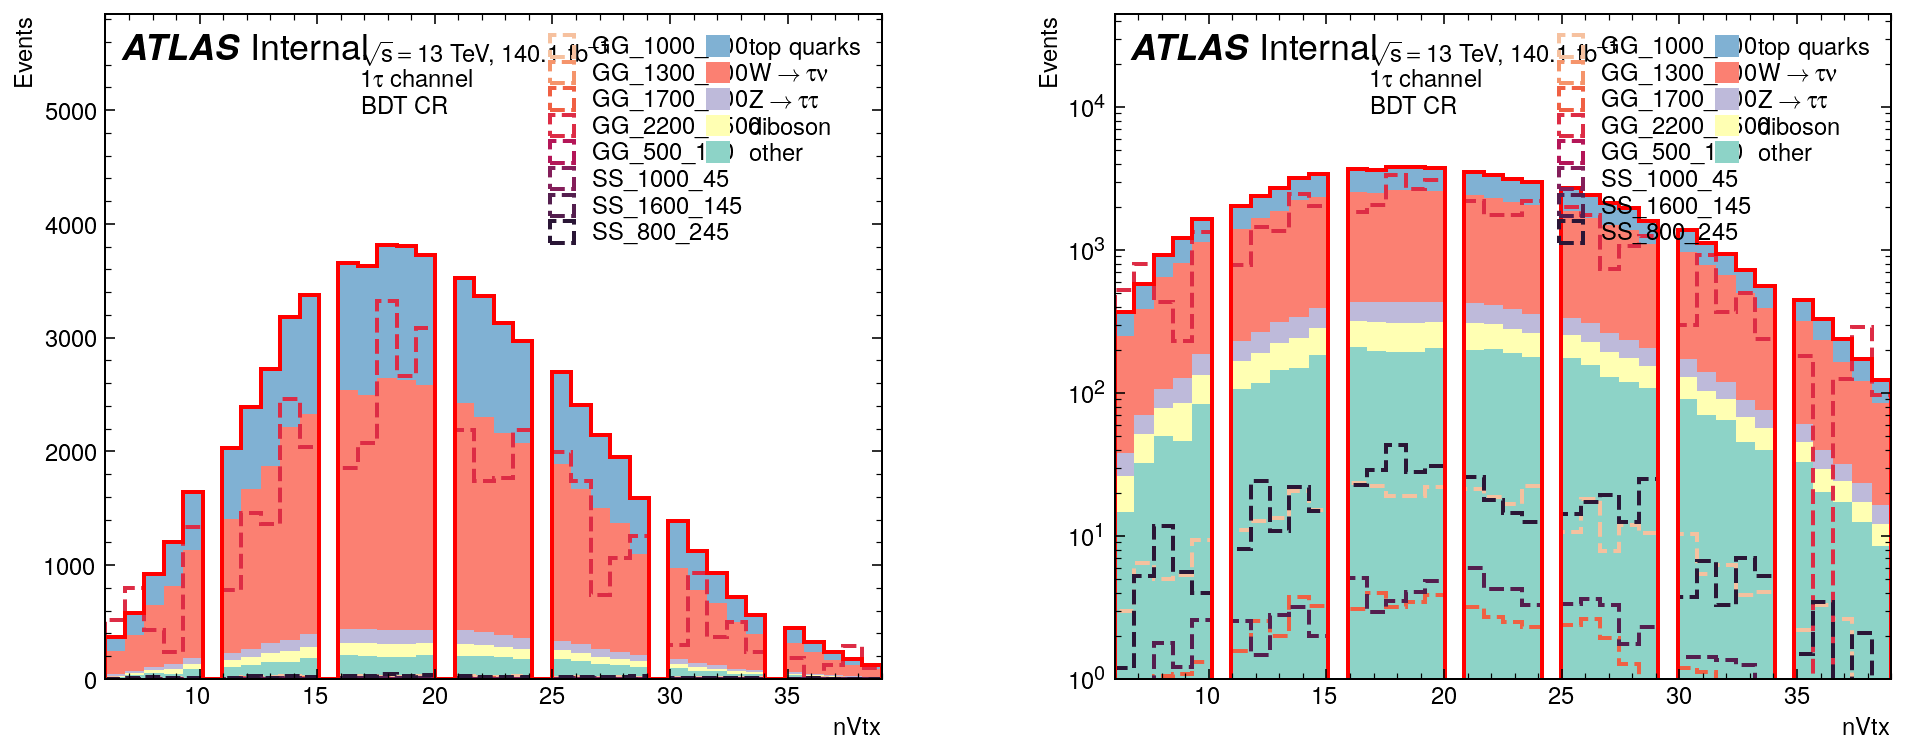

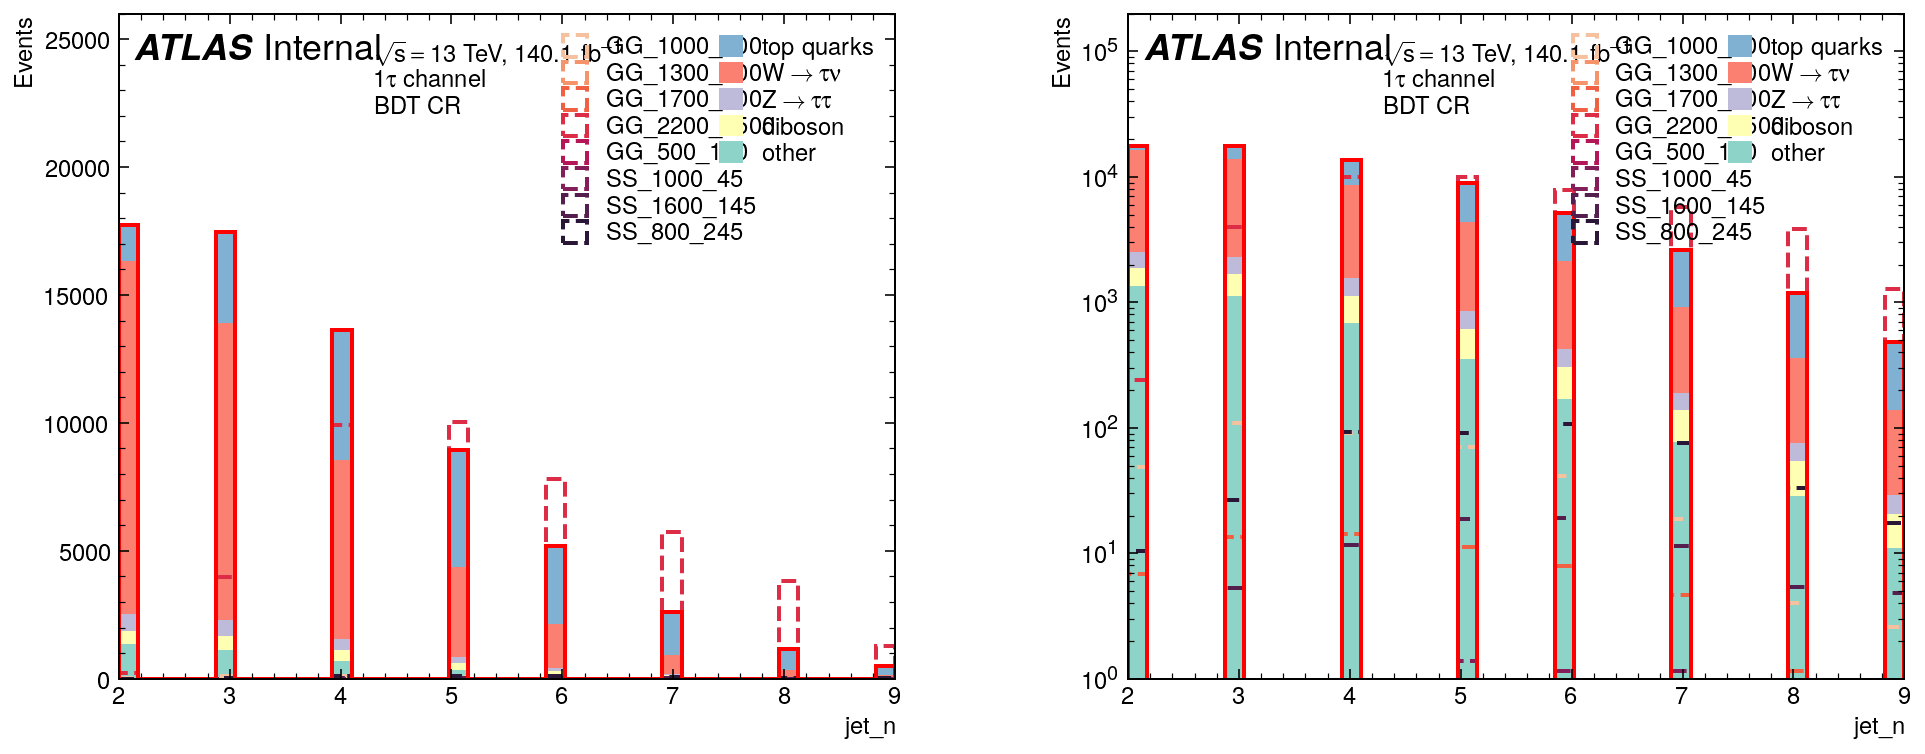

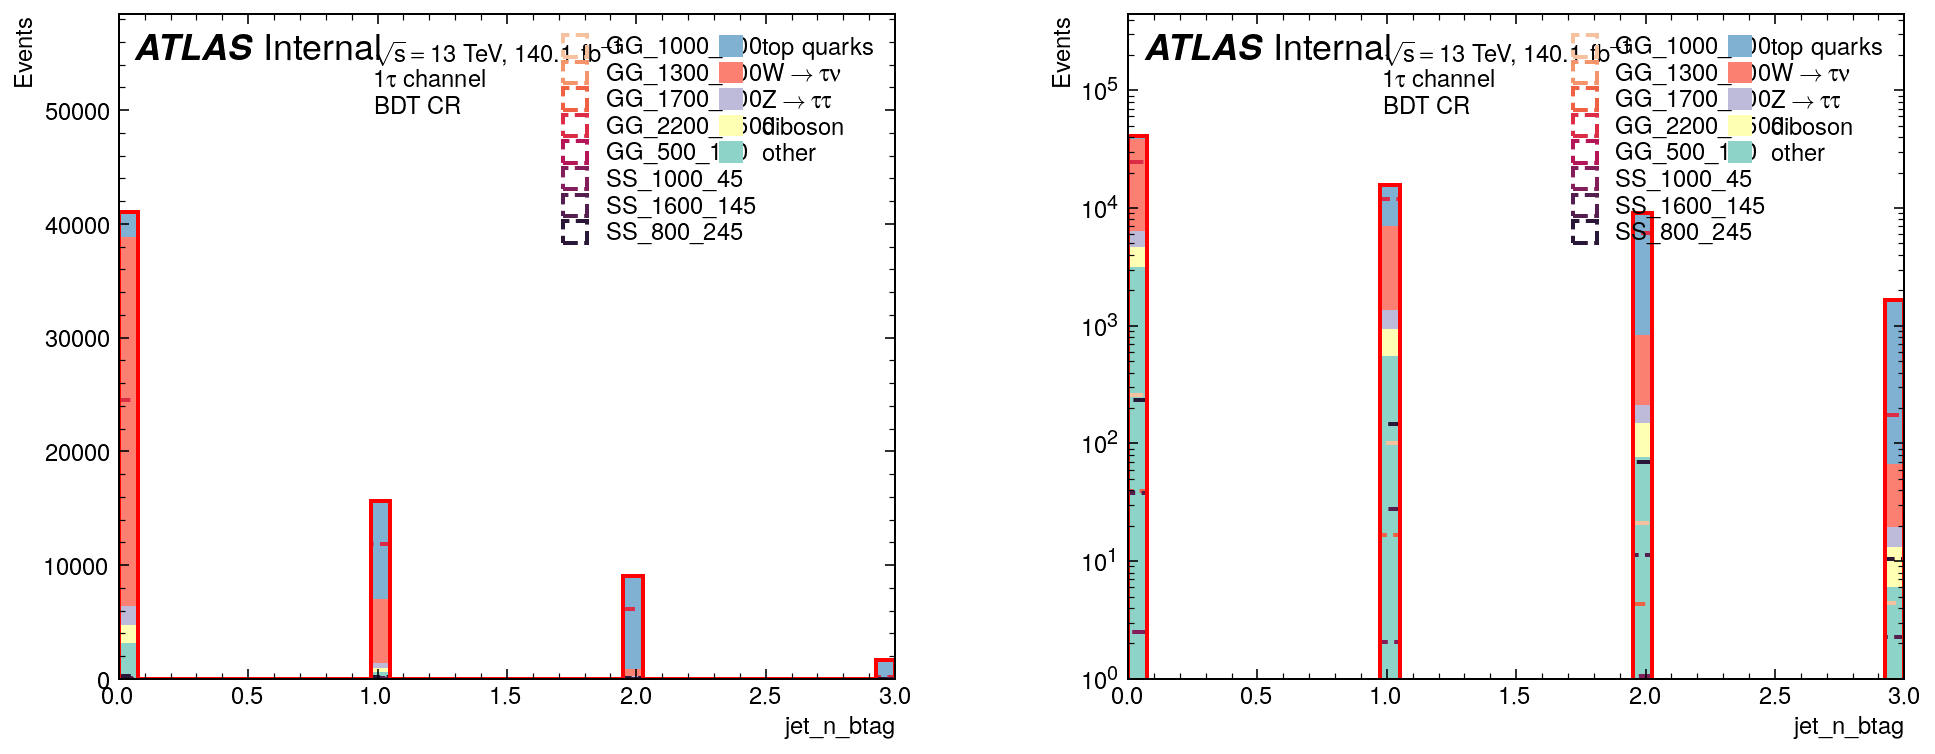

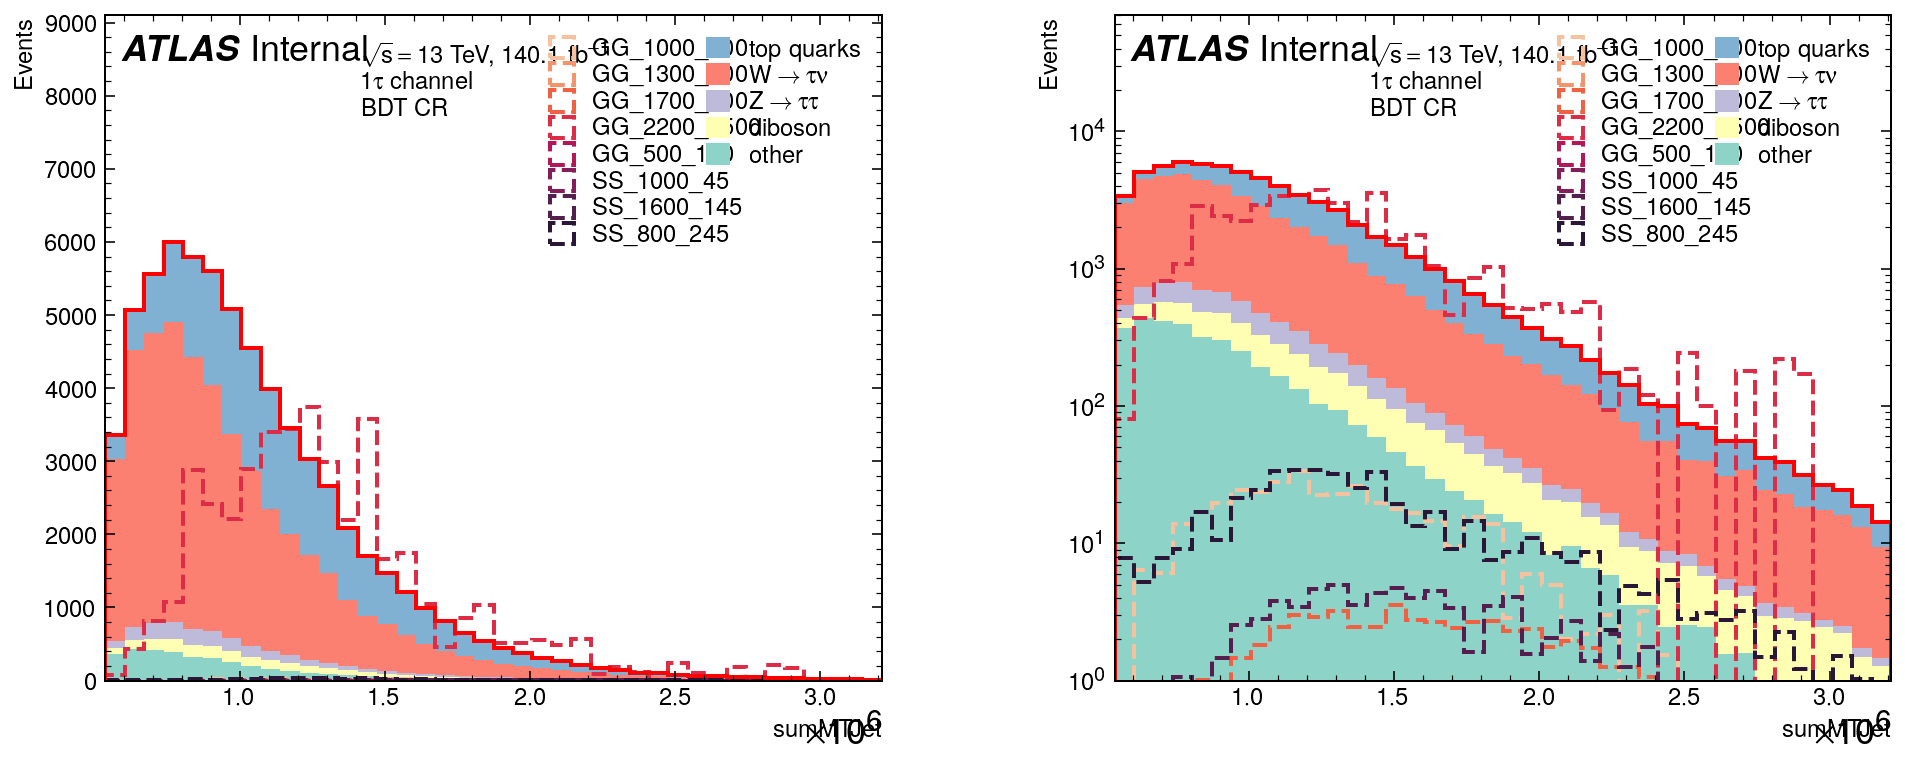

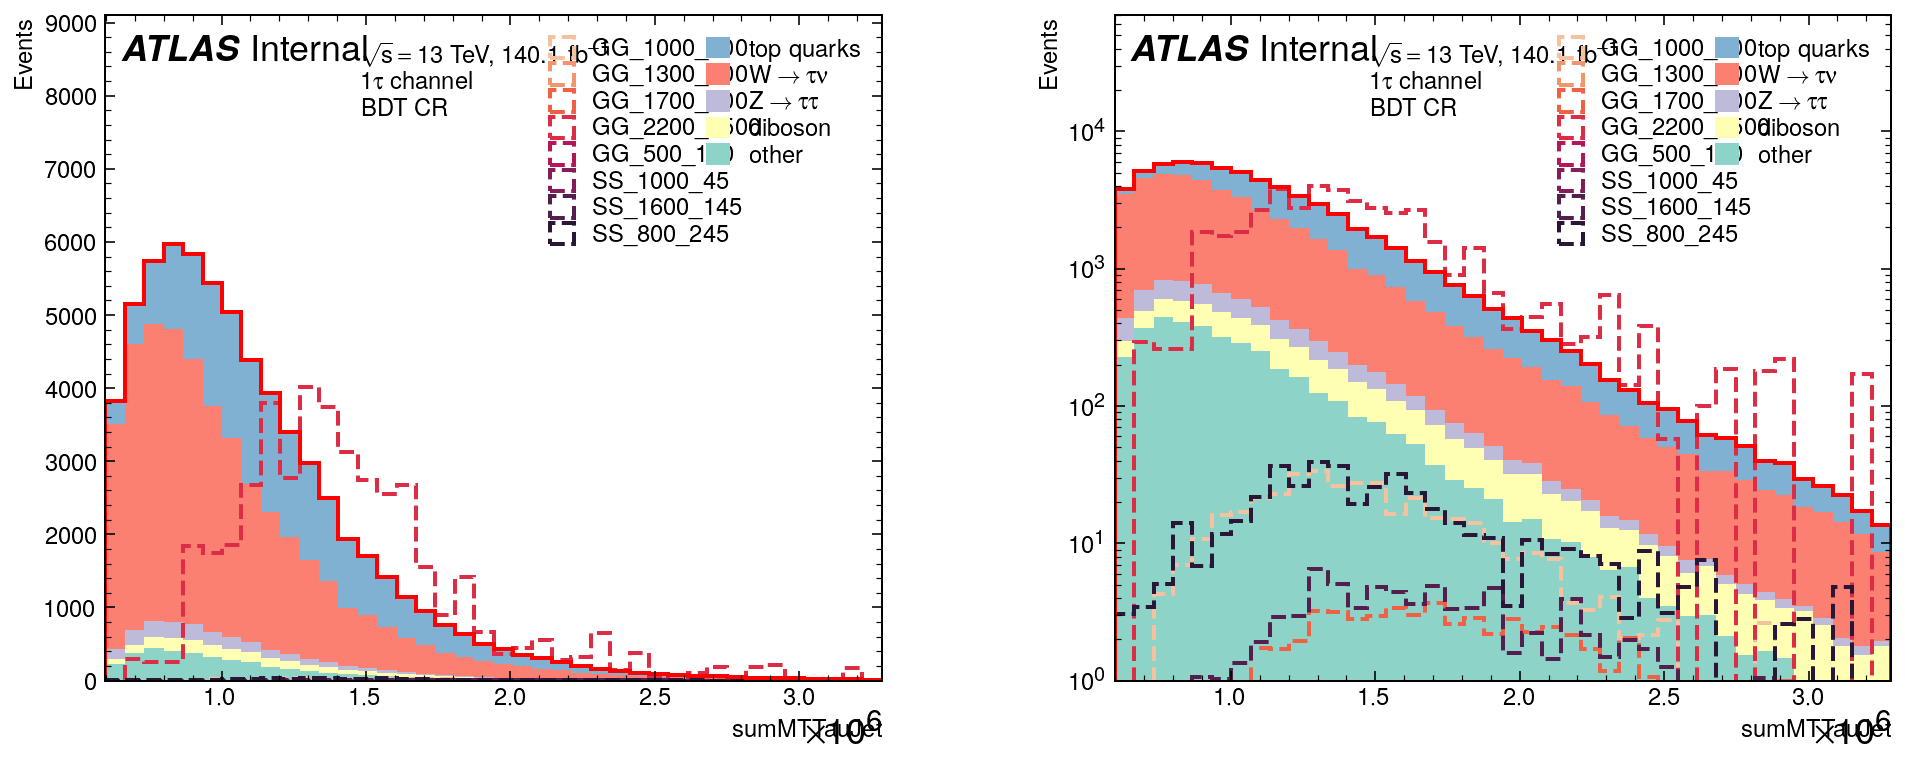

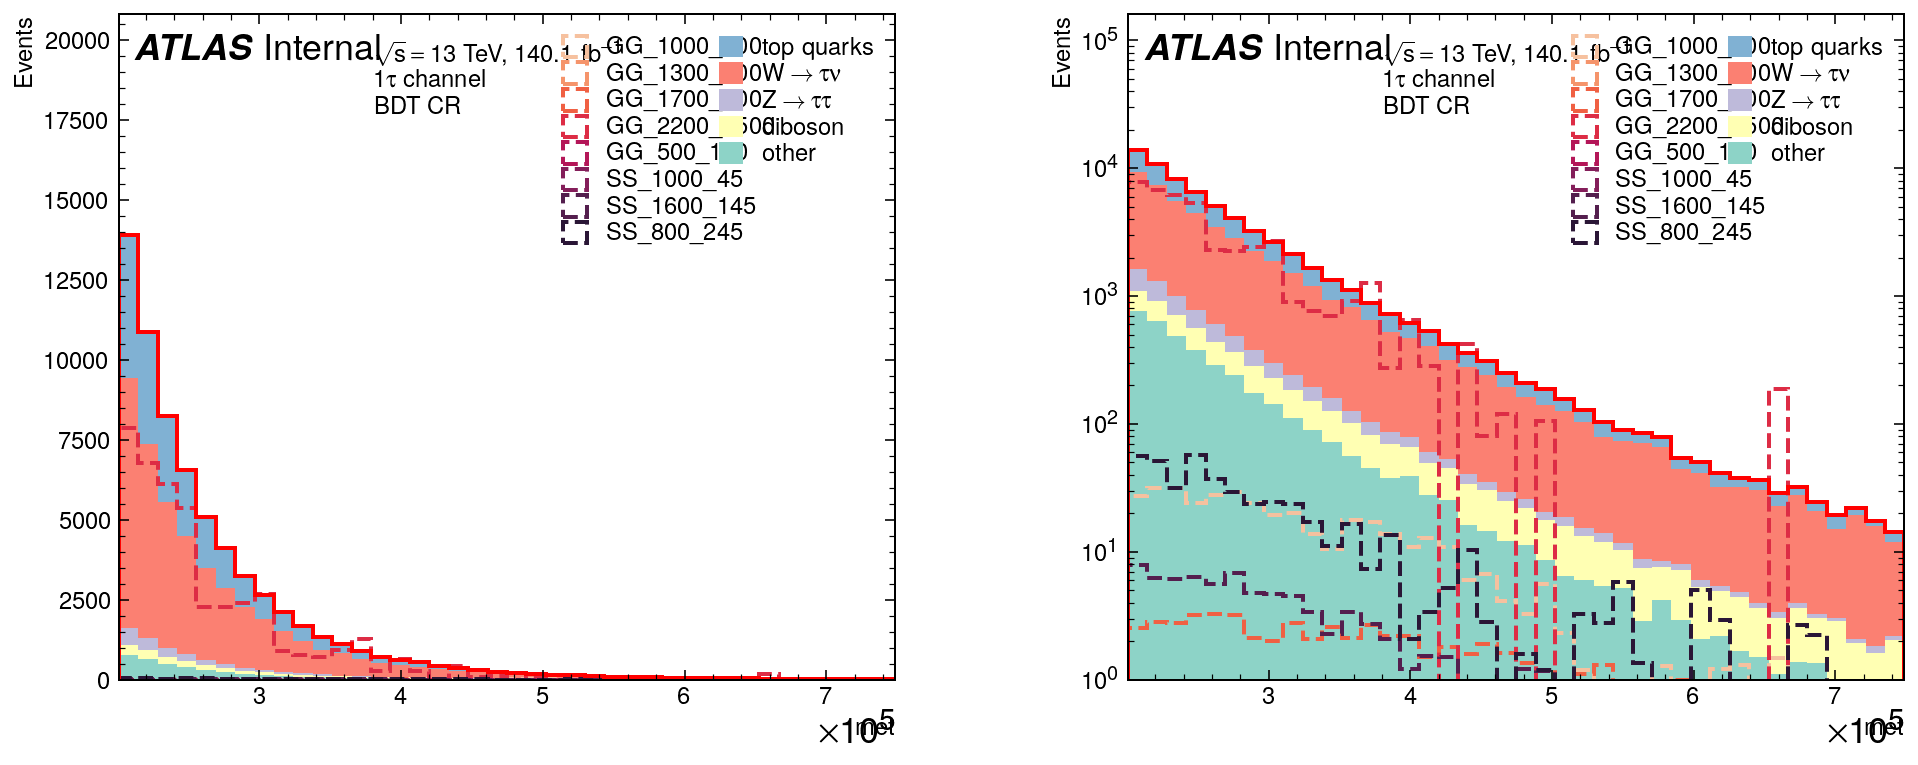

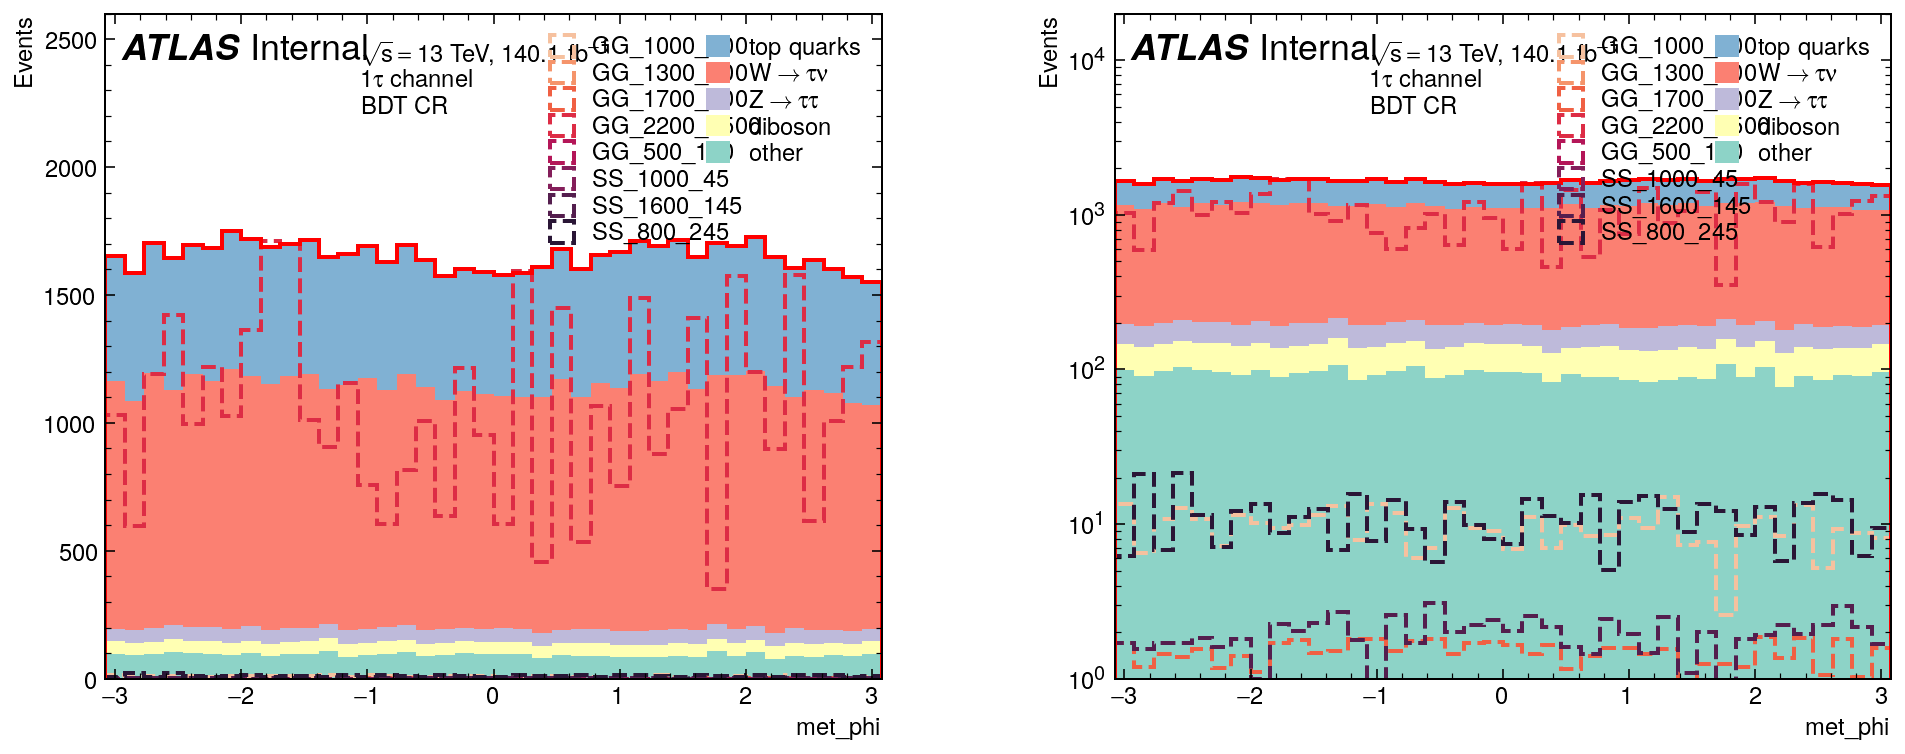

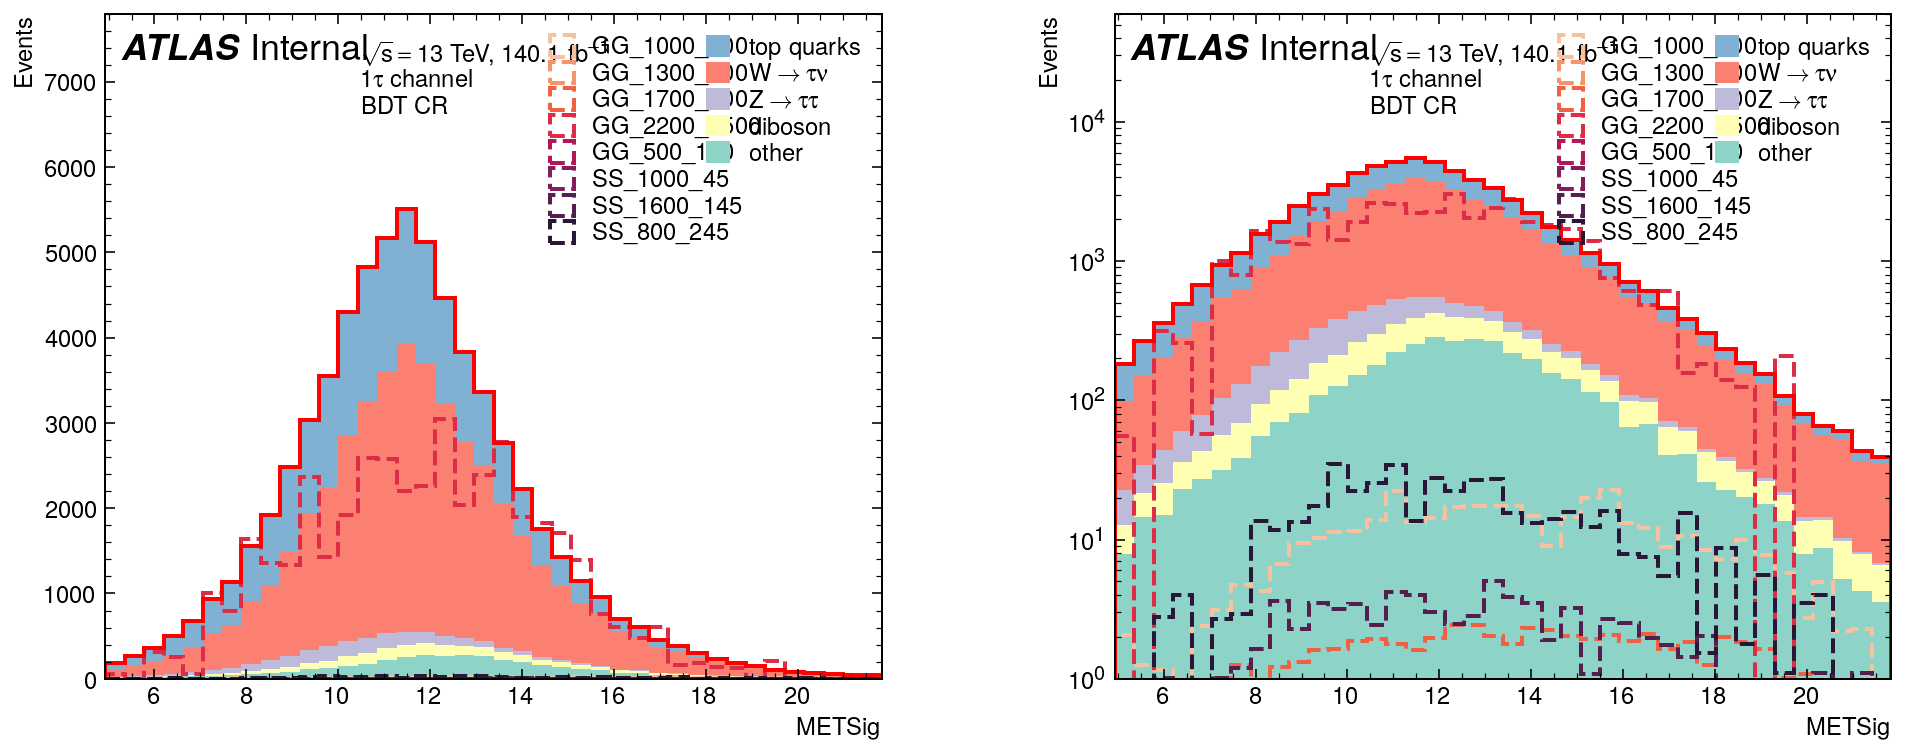

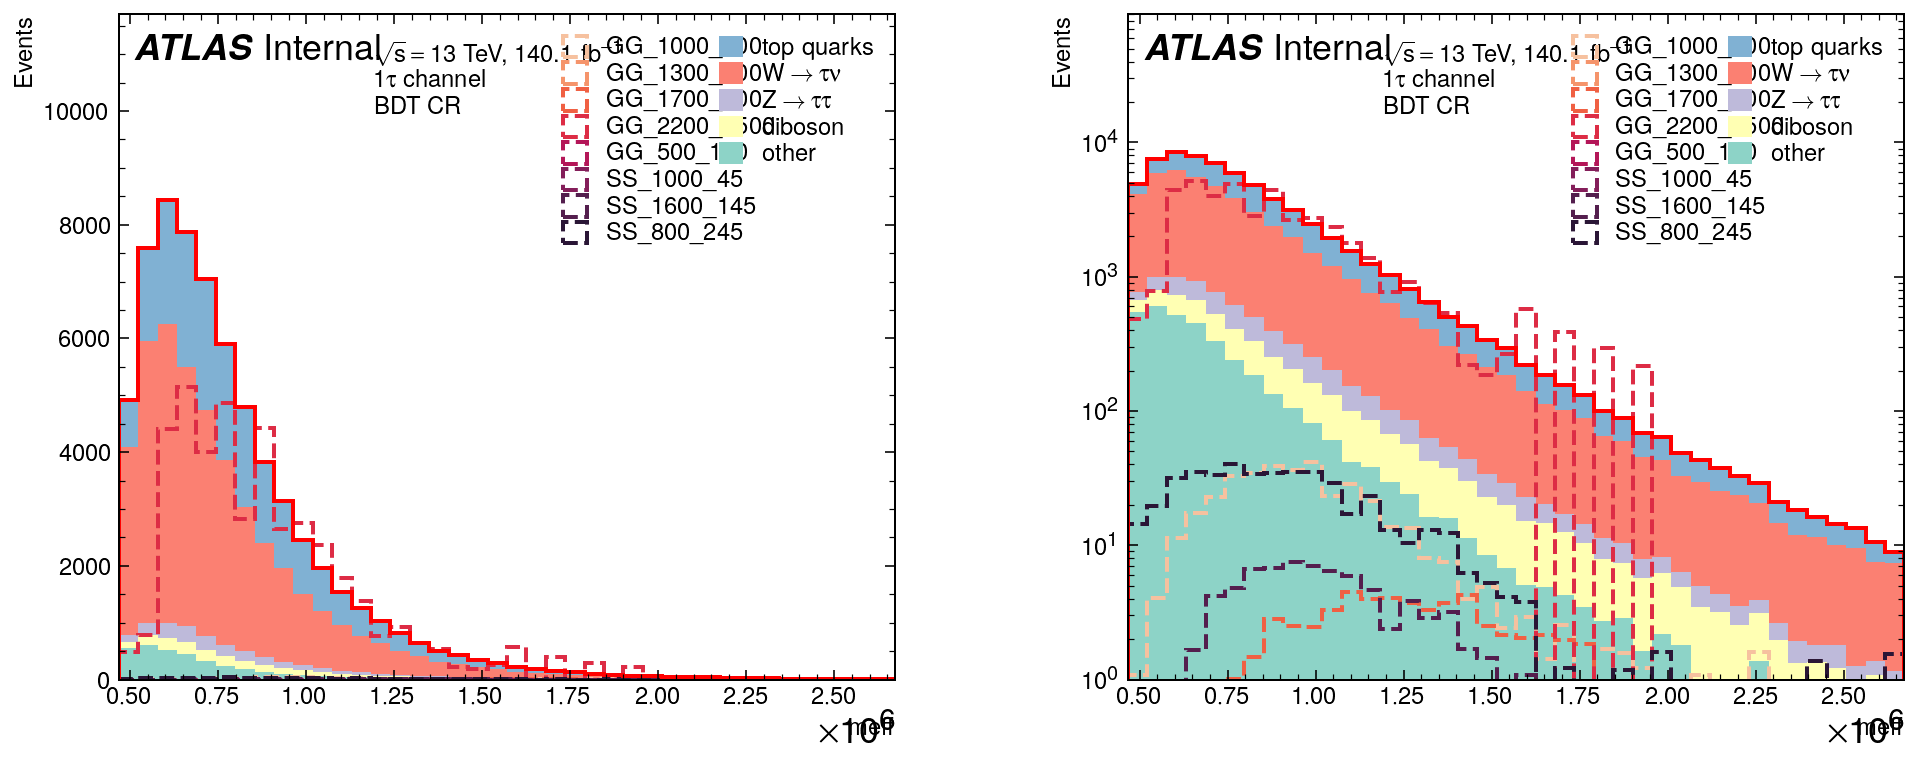

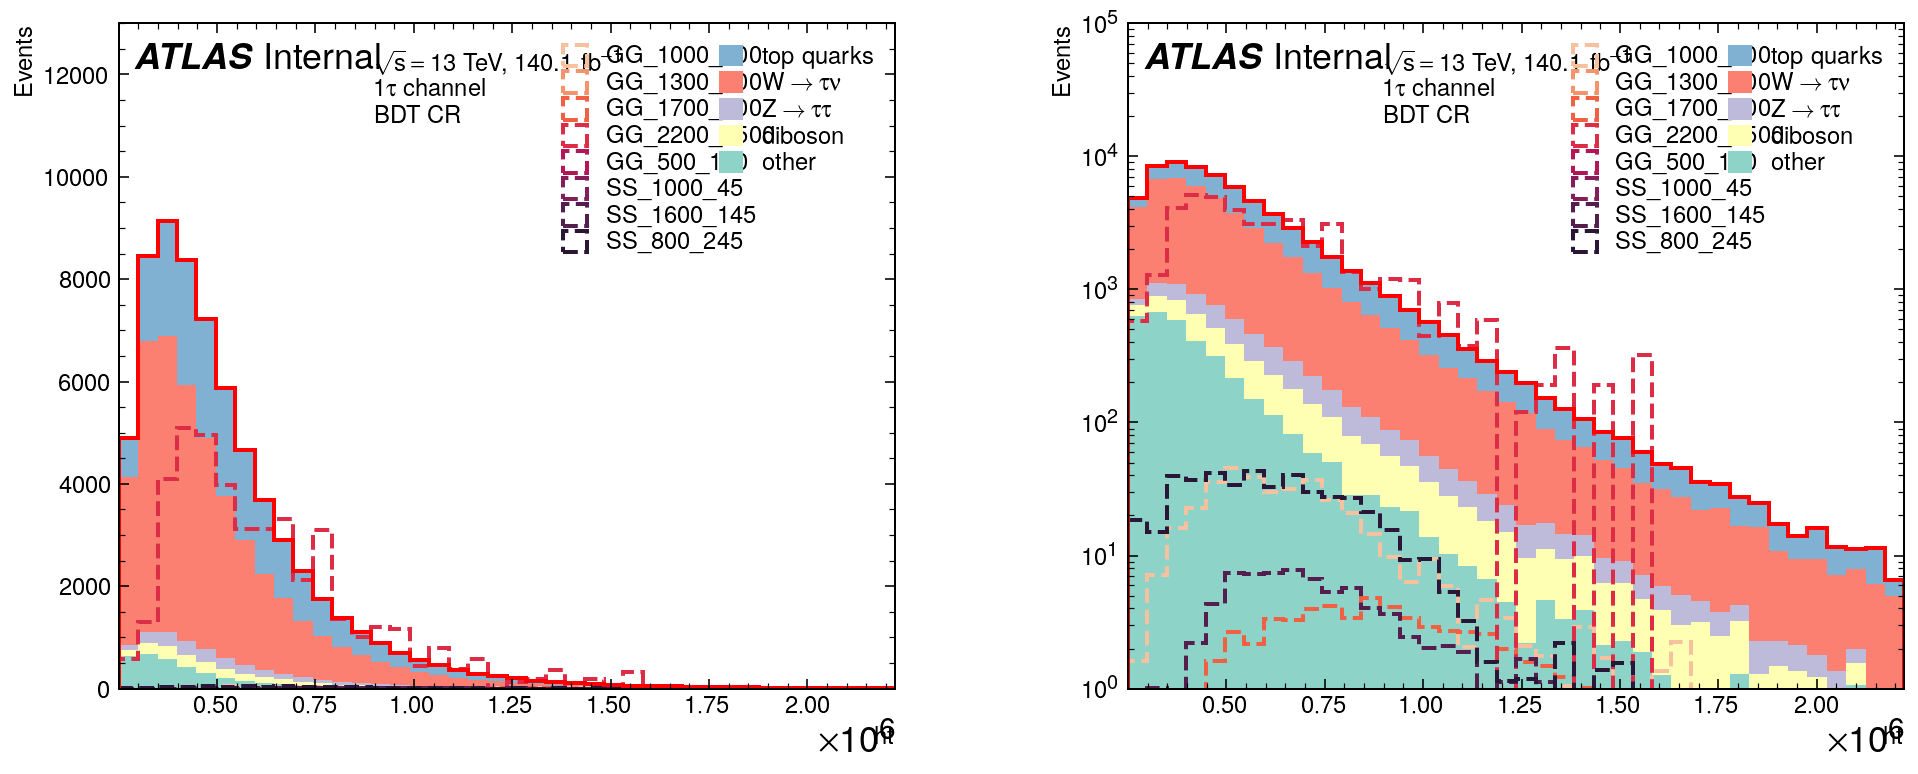

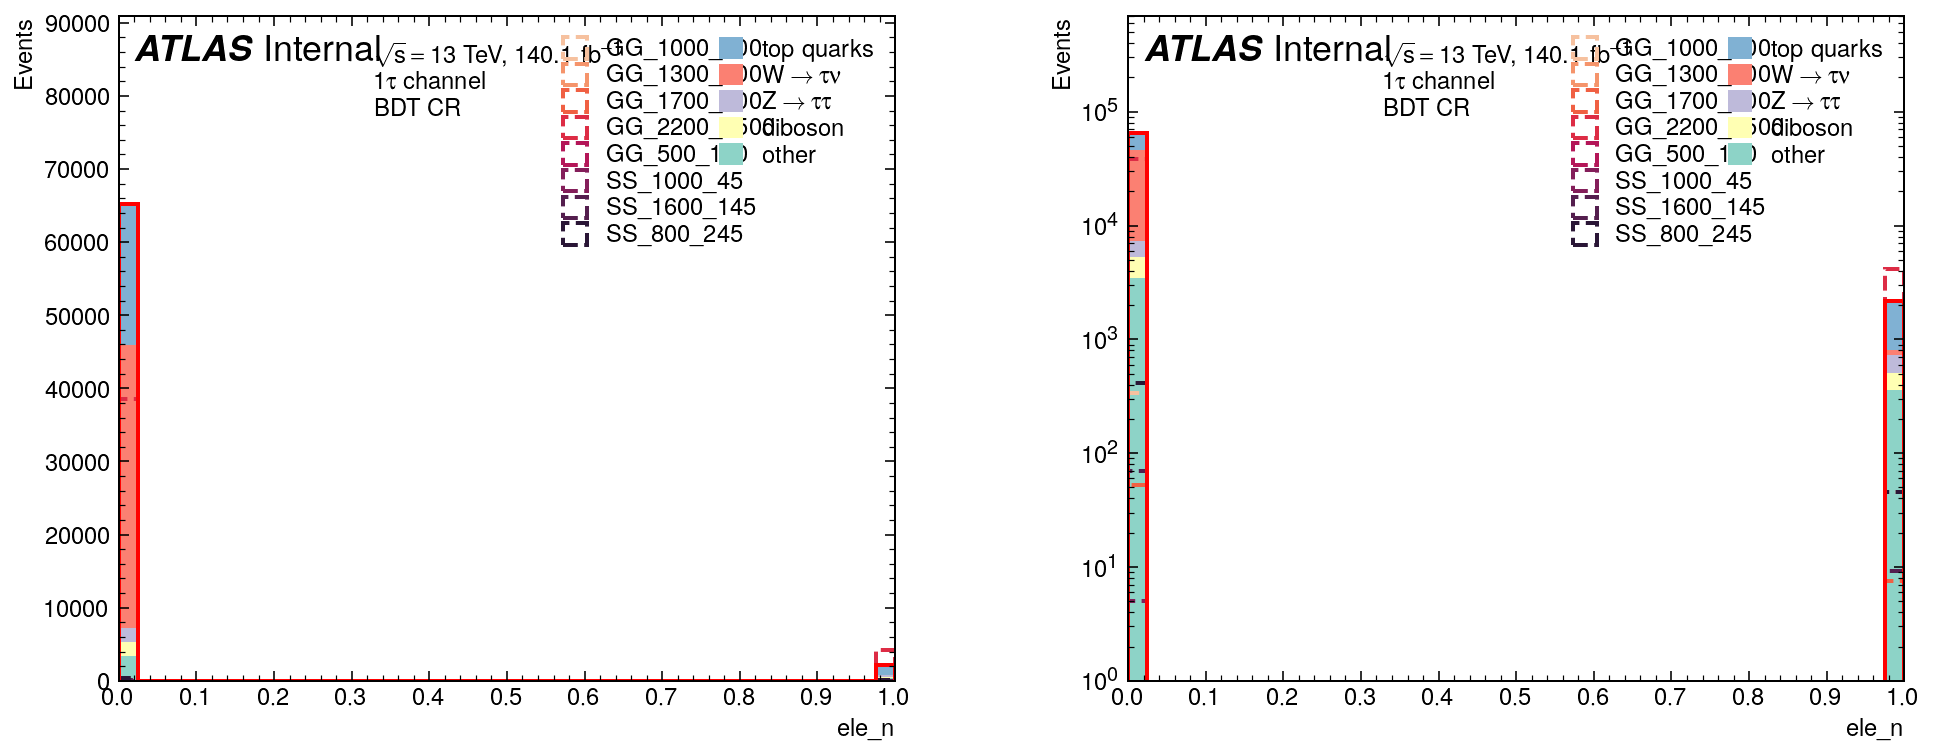

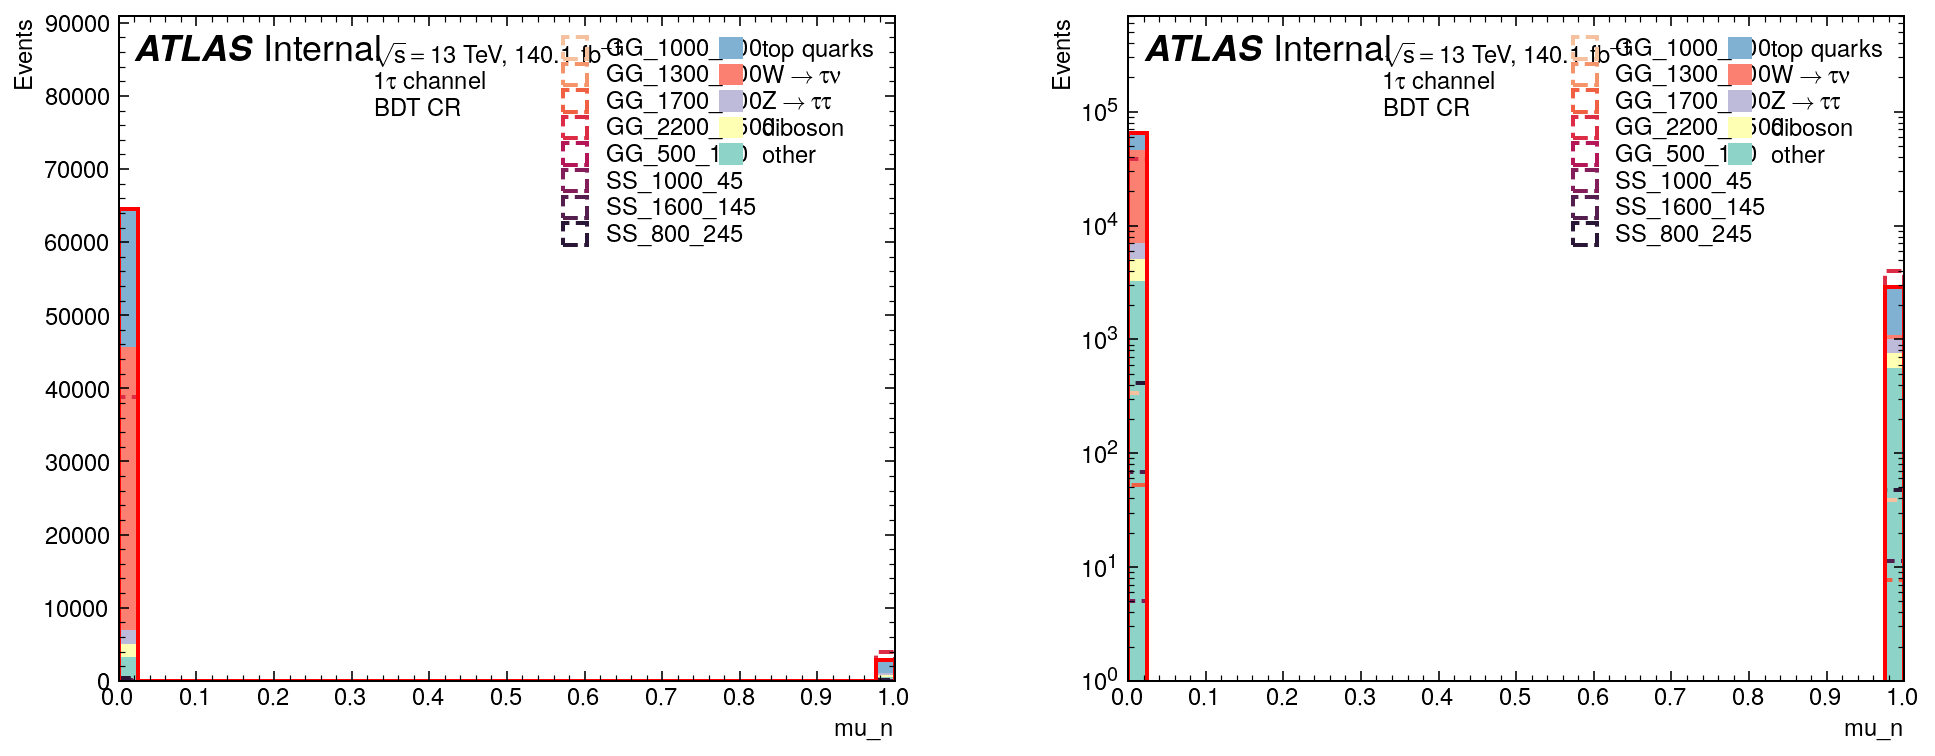

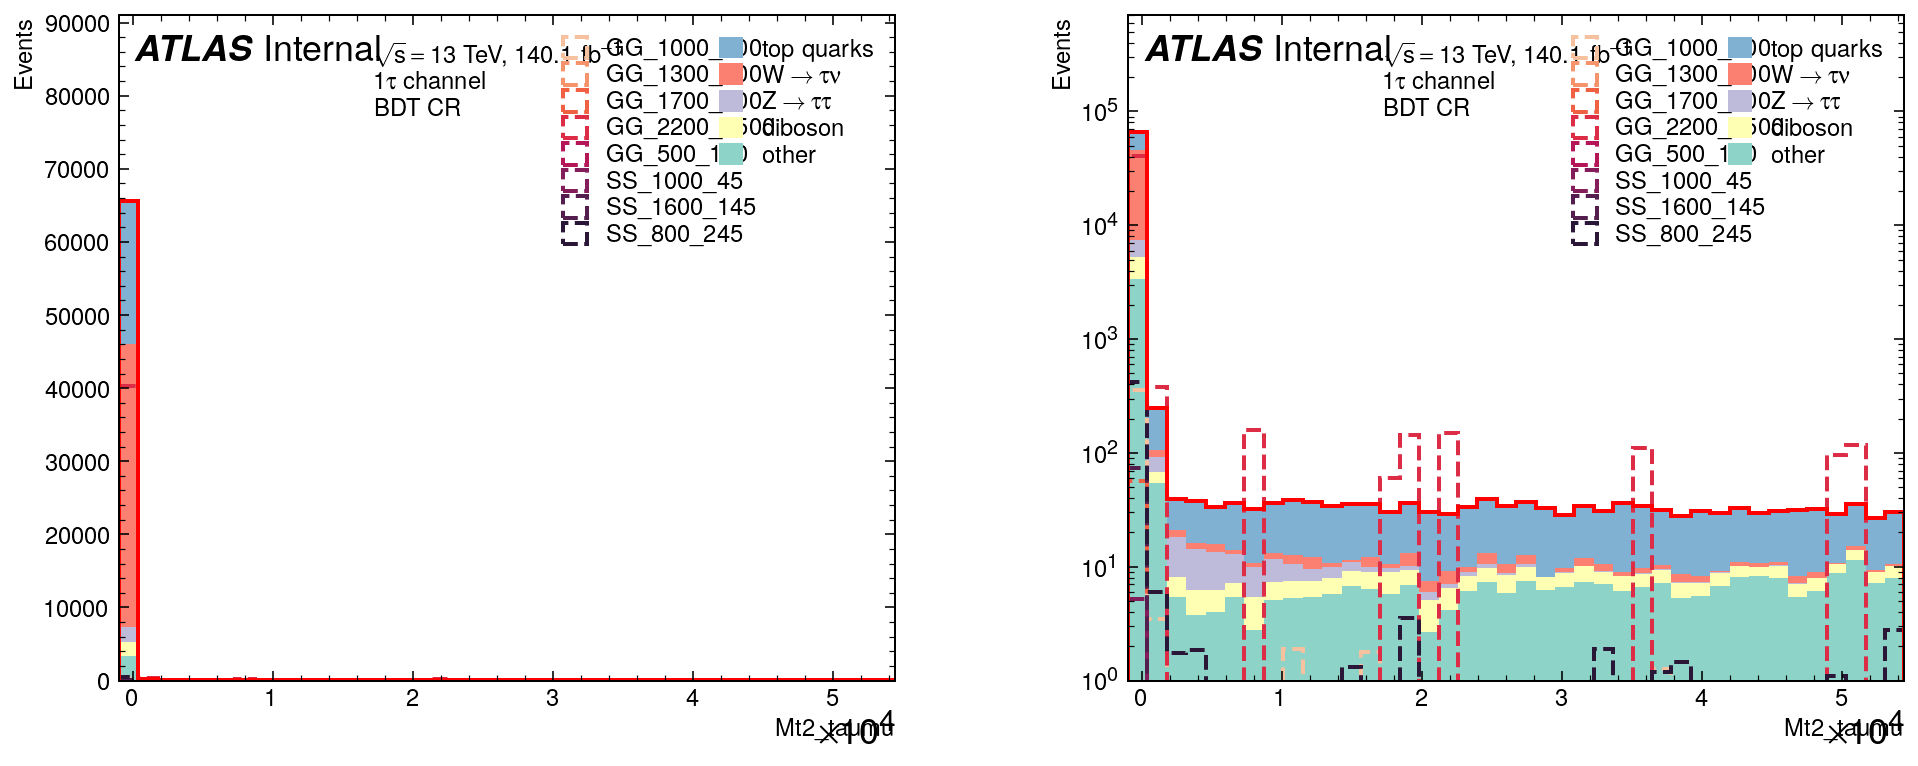

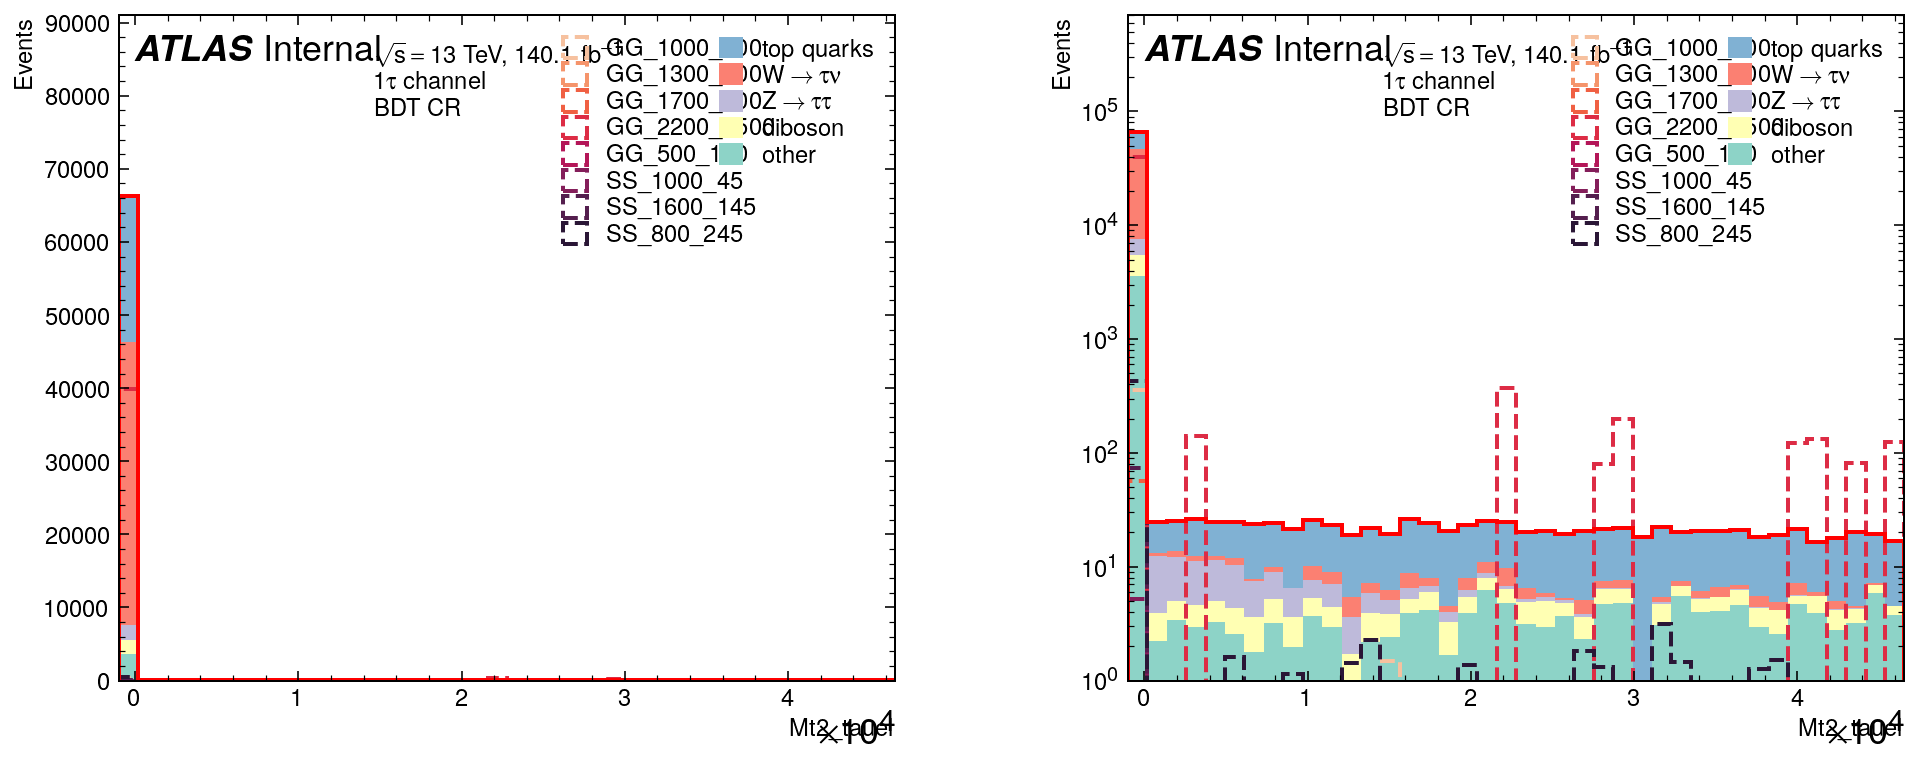

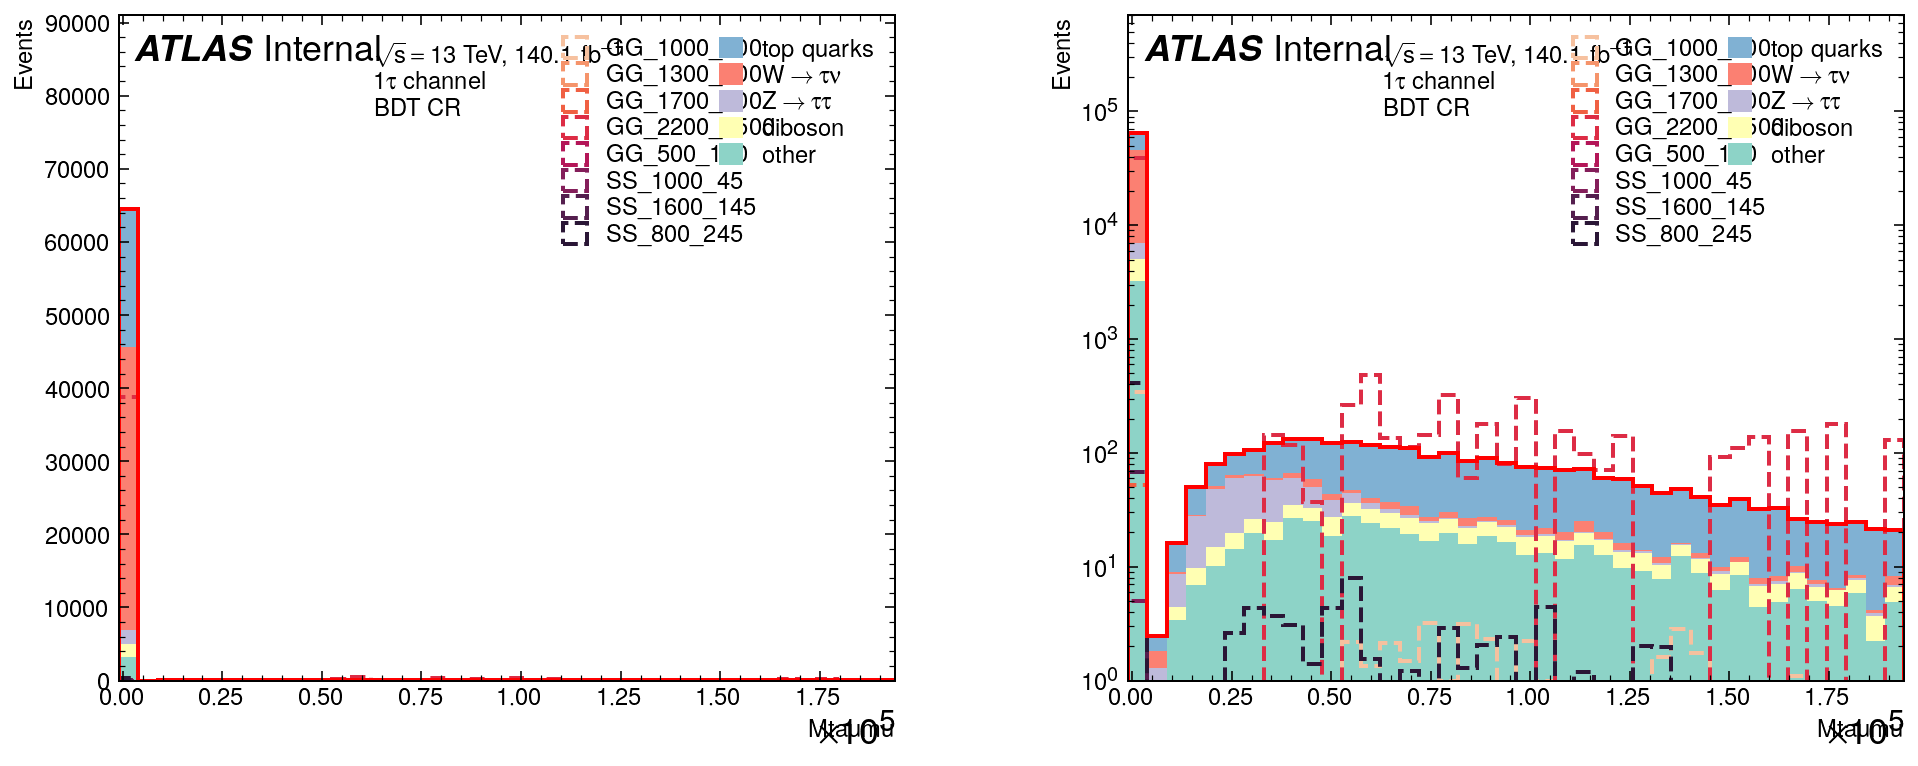

In [14]:
import matplotlib.pyplot as plt

selected_signals = list(kin_cfg.selected_signals)
plot_count = 0

for region_name, region_df in regions.items():
    bkg_dfs = {}
    for i, bkg_name in enumerate(background_names):
        mask = region_df["y_true"] == i
        if mask.any():
            bkg_dfs[background_display.get(bkg_name, bkg_name)] = region_df[mask]

    sig_dfs = {}
    if include_signal:
        for origin in selected_signals:
            mask = region_df["eventOrigin"] == origin
            if mask.any():
                sig_dfs[origin] = region_df[mask]

    for feat in training_features:
        vals = region_df[feat].dropna()
        if len(vals) == 0:
            continue

        lo, hi = float(vals.quantile(0.01)), float(vals.quantile(0.99))
        if lo == hi:
            continue

        fig = plot_kinematic_distribution(
            feature=feat,
            n_bins=40,
            xlim=(lo, hi),
            xlabel=feat,
            ylabel="Events",
            region=region_name,
            backgrounds=bkg_dfs,
            signals=sig_dfs if include_signal else None,
            run=cfg.analysis.run,
            channel=str(cfg.analysis.channel) if hasattr(cfg.analysis, "channel") else None,
            subject=model_type.upper(),
            scale=kin_cfg.scale,
            scale_factor=kin_cfg.scale_factor,
        )
        save_figure(fig, plots_dir / f"kin_{region_name}_{feat}.png")

        if plot_count < 15:
            plt.show()
            plot_count += 1
        plt.close(fig)

## Serialization

Optionally export the region DataFrames for downstream use.

In [15]:
from src.processing.io import save_dataframe

for region_name, region_df in regions.items():
    save_dataframe(
        region_df,
        dataframes_dir / f"{model_type}_{region_name.lower()}.parquet",
    )